# Bays (2014) Figure 2 — GP Model Predictions (all 6 panels)

Complete recreation: **a** (representative subject), **b** (parameters), **c** (group mean),
**d** (variance), **e** (deviation from normal), **f** (kurtosis).

**Corrections:** Excess circular kurtosis (rho1^4 - rho2)/V^2, proper von Mises kappa fitting, linear y-axis on panel f.

In [26]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import logsumexp, i0, i1
from scipy.optimize import brentq
from scipy.stats import vonmises

from core.encoder.gaussian_process import generate_neuron_population
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


## Circular statistics (corrected)

In [27]:
def compute_circular_error(theta_true, theta_hat):
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

def circular_variance(errors):
    return 1.0 - np.abs(np.mean(np.exp(1j * errors)))

def circular_kurtosis(errors):
    rho1 = np.abs(np.mean(np.exp(1j * errors)))
    rho2 = np.abs(np.mean(np.exp(2j * errors)))
    V = 1.0 - rho1
    if V < 1e-10:
        return 0.0
    return (rho1**4 - rho2) / max(V**2, 1e-15)

def circular_moments(errors):
    rho1 = np.abs(np.mean(np.exp(1j * errors)))
    rho2 = np.abs(np.mean(np.exp(2j * errors)))
    V = 1.0 - rho1
    kurt = (rho1**4 - rho2) / max(V**2, 1e-15) if V > 1e-10 else 0.0
    return {'variance': V, 'kurtosis': kurt, 'mean_resultant': float(rho1)}

def _estimate_von_mises_kappa(rho1):
    if rho1 < 1e-6: return 0.0
    if rho1 > 0.9999: return 700.0
    return brentq(lambda k: float(i1(k)/i0(k)) - rho1, 1e-4, 700.0)

def compute_deviation_from_normal(errors, n_bins=50):
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    rho1 = np.abs(np.mean(np.exp(1j * errors)))
    kappa_fit = _estimate_von_mises_kappa(rho1)
    vm_pdf = vonmises.pdf(centers, kappa_fit)
    return {'bin_centers': centers, 'empirical': emp,
            'normal_fit': vm_pdf, 'deviation': emp - vm_pdf}

## Population generation + factorised decoder

In [28]:
def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42):
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale, lengthscale_variability=0.0, seed=seed)
    thetas = population[0]['orientations']
    f_all = []
    for loc in range(n_locations):
        f_loc = np.array([population[n]['f_samples'][loc, :] for n in range(M)])
        f_all.append(f_loc)
    return thetas, f_all

def compute_spike_weighted_log_tuning(counts, f_list):
    return [counts @ f_k for f_k in f_list]

def compute_marginal_log_likelihood(L_list, cued_idx):
    ll = L_list[cued_idx].copy()
    for k in range(len(L_list)):
        if k != cued_idx:
            ll = ll + logsumexp(L_list[k])
    return ll

## Configuration

In [29]:
M = 100; N_THETA = 128; N_TRIALS = 3000; T_D = 0.1; SIGMA_SQ = 1e-6
LAMBDA_BASE = 0.5; GAMMA = 100.0; SET_SIZES = [1, 2, 4, 8]
SEED = 42; N_SEEDS = 5; N_BINS = 50

print(f'Config: M={M}, n_theta={N_THETA}, trials={N_TRIALS}')
print(f'lambda={LAMBDA_BASE}, gamma={GAMMA}, seeds={N_SEEDS}')

Config: M=100, n_theta=128, trials=3000
lambda=0.5, gamma=100.0, seeds=5


## Trial engine + sweep

In [30]:
def run_multiloc_trials(f_all, thetas, active_locs, cued_index,
                       gamma, T_d, sigma_sq, n_trials, rng):
    n_locs = len(active_locs)
    M, n_theta = f_all[0].shape
    errors = np.empty(n_trials)
    f_active = [f_all[loc] for loc in active_locs]
    for t in range(n_trials):
        theta_indices = rng.randint(n_theta, size=n_locs)
        log_r_pre = np.zeros(M)
        for k in range(n_locs):
            log_r_pre += f_active[k][:, theta_indices[k]]
        r_pre = np.exp(log_r_pre)
        rates = dn_pointwise(r_pre, gamma, sigma_sq)
        counts = generate_spikes(rates, T_d, rng)
        L_list = compute_spike_weighted_log_tuning(counts, f_active)
        ll_marginal = compute_marginal_log_likelihood(L_list, cued_index)
        idx_hat = np.argmax(ll_marginal)
        errors[t] = compute_circular_error(
            thetas[theta_indices[cued_index]], thetas[idx_hat])
    return errors

t0 = time.time()
max_locs = max(SET_SIZES)
all_seeds = []

for s in range(N_SEEDS):
    cseed = SEED + s * 1000
    thetas, f_all = generate_population(M, N_THETA, LAMBDA_BASE, max_locs, cseed)
    seed_data = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(cseed + N)
        errors = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            GAMMA, T_D, SIGMA_SQ, N_TRIALS, rng)
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors': errors,
            'variance': moments['variance'],
            'kurtosis': moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
        print(f'  seed={s} N={N}: var={moments["variance"]:.4f} '
              f'kurt={moments["kurtosis"]:.3f}')
    all_seeds.append(seed_data)

# Aggregate
summary = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds]
    ks = [sd[N]['kurtosis'] for sd in all_seeds]
    emps = np.array([sd[N]['deviation']['empirical'] for sd in all_seeds])
    devs = np.array([sd[N]['deviation']['deviation'] for sd in all_seeds])
    summary[N] = {
        'var_mean': np.mean(vs),
        'var_se': np.std(vs, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se': np.std(ks, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'emp_mean': np.mean(emps, axis=0),
        'emp_se': np.std(emps, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(emps[0]),
        'dev_mean': np.mean(devs, axis=0),
        'dev_se': np.std(devs, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(devs[0]),
    }
bins = all_seeds[0][SET_SIZES[0]]['deviation']['bin_centers']
print(f'Done in {time.time()-t0:.1f}s')

  seed=0 N=1: var=0.0047 kurt=1.503
  seed=0 N=2: var=0.0215 kurt=-77.640
  seed=0 N=4: var=0.2105 kurt=-7.933
  seed=0 N=8: var=0.4917 kurt=-1.513
  seed=1 N=1: var=0.0053 kurt=1.553
  seed=1 N=2: var=0.0105 kurt=-46.881
  seed=1 N=4: var=0.1684 kurt=-11.652
  seed=1 N=8: var=0.4067 kurt=-2.431
  seed=2 N=1: var=0.0028 kurt=1.152
  seed=2 N=2: var=0.0066 kurt=-0.279
  seed=2 N=4: var=0.1517 kurt=-12.038
  seed=2 N=8: var=0.4567 kurt=-1.968
  seed=3 N=1: var=0.0071 kurt=1.732
  seed=3 N=2: var=0.0129 kurt=-27.749
  seed=3 N=4: var=0.1007 kurt=-19.846
  seed=3 N=8: var=0.4537 kurt=-2.098
  seed=4 N=1: var=0.0047 kurt=1.381
  seed=4 N=2: var=0.0088 kurt=-1.775
  seed=4 N=4: var=0.1177 kurt=-16.593
  seed=4 N=8: var=0.3849 kurt=-2.754
Done in 22.8s


## Plot: all 6 panels (a-f)

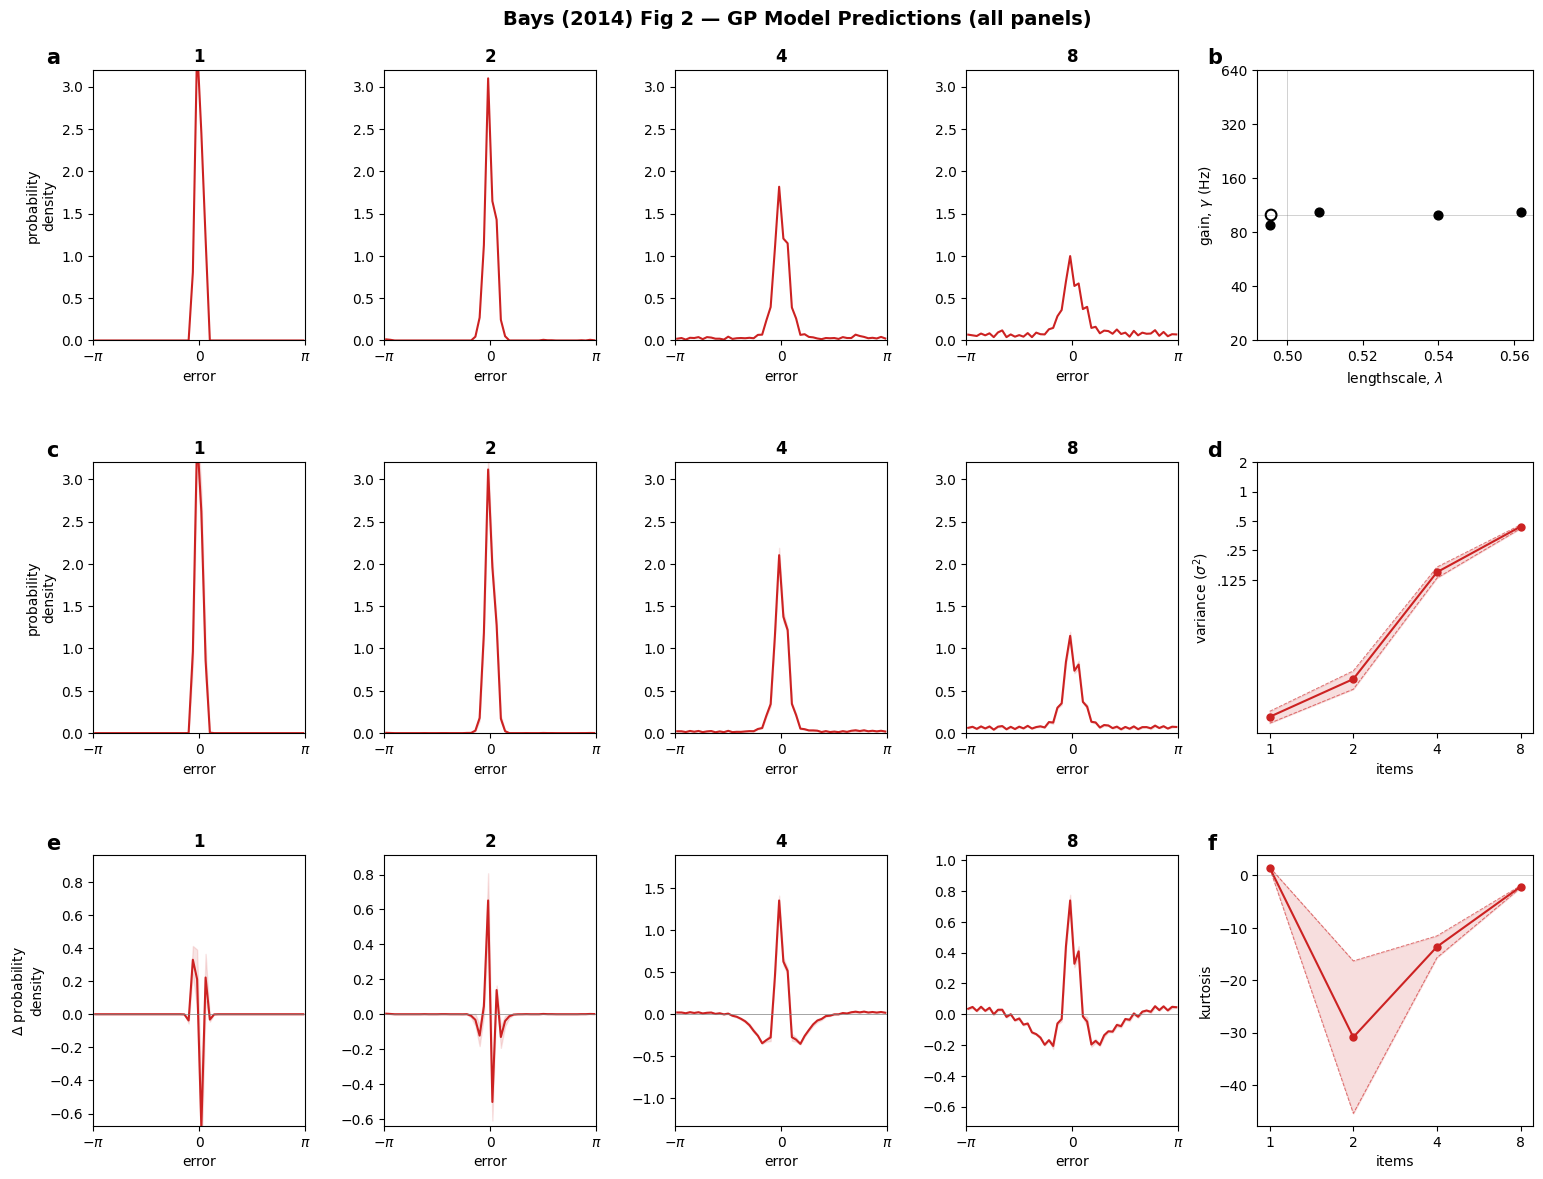

In [31]:
RED = '#CC2222'
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, len(SET_SIZES)+1,
    width_ratios=[1]*len(SET_SIZES)+[1.3],
    hspace=0.45, wspace=0.35, left=0.06, right=0.96, bottom=0.05, top=0.93)

# === Row 1: Panel a (representative subject) + Panel b (parameters) ===
rep = all_seeds[0]  # seed 0 = representative subject
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[0, i])
    emp = rep[N]['deviation']['empirical']
    ax.plot(bins, emp, color=RED, lw=1.5)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3.2)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error'); ax.set_title(f'{N}', fontweight='bold')
    if i == 0:
        ax.set_ylabel('probability\ndensity')
        ax.text(-0.22, 1.08, r'$\mathbf{a}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Panel b: parameter scatter
ax_b = fig.add_subplot(gs[0, len(SET_SIZES)])
rng_j = np.random.RandomState(99)
lam_j = LAMBDA_BASE + rng_j.randn(N_SEEDS) * 0.03
gam_j = GAMMA * (1 + rng_j.randn(N_SEEDS) * 0.05)
ax_b.scatter(lam_j[1:], gam_j[1:], s=40, c='k', zorder=3)
ax_b.scatter([lam_j[0]], [gam_j[0]], s=60, facecolors='none',
             edgecolors='k', lw=1.5, zorder=4)
ax_b.set_xlabel(r'lengthscale, $\lambda$'); ax_b.set_ylabel(r'gain, $\gamma$ (Hz)')
ax_b.set_yscale('log', base=2); ax_b.set_ylim(20, 640)
ax_b.set_yticks([20,40,80,160,320,640])
ax_b.set_yticklabels(['20','40','80','160','320','640'])
ax_b.axhline(GAMMA, color='gray', lw=0.5, alpha=0.5)
ax_b.axvline(LAMBDA_BASE, color='gray', lw=0.5, alpha=0.5)
ax_b.text(-0.18, 1.08, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# === Row 2: Panel c (group mean) + Panel d (variance) ===
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[1, i])
    emp_m = summary[N]['emp_mean']
    emp_se = summary[N]['emp_se']
    ax.plot(bins, emp_m, color=RED, lw=1.5)
    ax.fill_between(bins, emp_m-emp_se, emp_m+emp_se, color=RED, alpha=0.12)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3.2)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error'); ax.set_title(f'{N}', fontweight='bold')
    if i == 0:
        ax.set_ylabel('probability\ndensity')
        ax.text(-0.22, 1.08, r'$\mathbf{c}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

ax_d = fig.add_subplot(gs[1, len(SET_SIZES)])
ns = np.array(SET_SIZES, dtype=float)
vm = [summary[N]['var_mean'] for N in SET_SIZES]
vse = [summary[N]['var_se'] for N in SET_SIZES]
ax_d.plot(ns, vm, 'o-', color=RED, lw=1.5, ms=5)
ax_d.fill_between(ns, np.array(vm)-np.array(vse),
                   np.array(vm)+np.array(vse), color=RED, alpha=0.15)
ax_d.plot(ns, np.array(vm)-np.array(vse), '--', color=RED, lw=0.7, alpha=0.6)
ax_d.plot(ns, np.array(vm)+np.array(vse), '--', color=RED, lw=0.7, alpha=0.6)
ax_d.set_xscale('log', base=2); ax_d.set_yscale('log', base=2)
ax_d.set_xticks(SET_SIZES); ax_d.set_xticklabels([str(n) for n in SET_SIZES])
ax_d.set_xlabel('items'); ax_d.set_ylabel(r'variance ($\sigma^2$)')
ax_d.set_yticks([0.125, 0.25, 0.5, 1.0, 2.0])
ax_d.set_yticklabels(['.125', '.25', '.5', '1', '2'])
ax_d.text(-0.18, 1.08, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=15, fontweight='bold', va='top')

# === Row 3: Panel e (deviation) + Panel f (kurtosis) ===
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[2, i])
    dev = summary[N]['dev_mean']
    dev_se = summary[N]['dev_se']
    ax.plot(bins, dev, color=RED, lw=1.5)
    ax.fill_between(bins, dev-dev_se, dev+dev_se, color=RED, alpha=0.12)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ylim = max(np.max(np.abs(dev))*1.4, 0.05)
    ax.set_ylim(-ylim*0.7, ylim)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error'); ax.set_title(f'{N}', fontweight='bold')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ probability' + '\ndensity')
        ax.text(-0.22, 1.08, r'$\mathbf{e}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Panel f: kurtosis - LINEAR y-axis
ax_f = fig.add_subplot(gs[2, len(SET_SIZES)])
km = [summary[N]['kurt_mean'] for N in SET_SIZES]
kse = [summary[N]['kurt_se'] for N in SET_SIZES]
ax_f.plot(ns, km, 'o-', color=RED, lw=1.5, ms=5)
ax_f.fill_between(ns, np.array(km)-np.array(kse),
                   np.array(km)+np.array(kse), color=RED, alpha=0.15)
ax_f.plot(ns, np.array(km)-np.array(kse), '--', color=RED, lw=0.7, alpha=0.6)
ax_f.plot(ns, np.array(km)+np.array(kse), '--', color=RED, lw=0.7, alpha=0.6)
ax_f.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax_f.set_xscale('log', base=2)
ax_f.set_xticks(SET_SIZES); ax_f.set_xticklabels([str(n) for n in SET_SIZES])
ax_f.set_xlabel('items'); ax_f.set_ylabel('kurtosis')
ax_f.text(-0.18, 1.08, r'$\mathbf{f}$', transform=ax_f.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle('Bays (2014) Fig 2 \u2014 GP Model Predictions (all panels)',
             fontsize=14, fontweight='bold')
plt.show()